# Predict regulatory regions around LMNA (AlphaGenome)

This notebook runs AlphaGenome interval predictions for left-ventricle heart tissue around *LMNA*, isolates high-signal candidate regulatory regions from chromatin and transcription modalities, exports per-modality / per-histone peaks as BED, collapses completely nested intervals into parent/member tables, and overlays the collapsed regions (colored by modality or histone mark) on multi-track plots.

**Run with the AG kernel.**


# Setup

Load libraries, shared paths and constants, the AlphaGenome model, and GENCODE transcript extractors used throughout.


## Imports

Import AlphaGenome model/genome/transcript helpers, plotting utilities, and pandas/numpy.

**Make sure to run using AG kernel**


In [1]:
from alphagenome_research.model import dna_model
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript
from alphagenome.models import dna_client
from alphagenome.visualization import plot_components
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)


/users/PAS2905/coraalbers/.conda/envs/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Common use variables

Define LMNA coordinates and filesystem paths, heart/LV ontology curies (`HEART_UB`, `LV_UB`), requested AlphaGenome output modalities, `MODALITY_COLORS` / `HISTONE_MARKS` / `HISTONE_COLORS`, ENCODE-style `CCRE_COLORS`, and `TSS_BED_PATH` for cCRE-like classification.


In [2]:
LMNA_START = 156_114_711
LMNA_END = 156_140_081
gene_symbol = "LMNA"
LMNA_INTERVAL = genome.Interval('chr1', 156_114_711, 156_140_081)


BASE_PATH = '/users/PAS2905/coraalbers/'
AG_DATA_PATH = '/users/PAS2905/coraalbers/ag/ag_data/'

HG38_FASTA_PATH = '/users/PAS2905/coraalbers/ag/hg38.fa'
HG38_GTF_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.annotation.gtf.gz.feather'
HG38_SPLICE_START_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.splice_sites_starts.feather'
HG38_SPLICE_END_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.splice_sites_ends.feather'

HEART_UB = 'UBERON:0000948' # heart
LV_UB = 'UBERON:0002084' # LV

# HG38_GTF_PATH = pd.read_feather( 'https://storage.googleapis.com/alphagenome/reference/gencode/' 'hg38/gencode.v46.annotation.gtf.gz.feather' )

output_modalities = ['atac',	
    'cage',	
    'chip_histone',	
    'chip_tf',	
    'contact_maps',	
    'dnase',	
    'procap',	
    'rna_seq',	
    'splice_junctions',	
    'splice_site_usage',	
    'splice_sites']

requested_outputs = {dna_client.OutputType.ATAC,
        dna_client.OutputType.CAGE,
        dna_client.OutputType.DNASE,
        dna_client.OutputType.PROCAP,
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.SPLICE_SITES,
        dna_client.OutputType.SPLICE_SITE_USAGE,
        dna_client.OutputType.SPLICE_JUNCTIONS,
        dna_client.OutputType.CONTACT_MAPS,
        dna_client.OutputType.CHIP_HISTONE,
        dna_client.OutputType.CHIP_TF}


MODALITY_COLORS = {
    "dnase": "#e377c2",          # pink
    "atac": "#17becf",           # cyan
    "chip_histone": "#d62728",   # red
    "chip_tf": "#9467bd",        # purple
    "rna_seq": "#2ca02c",        # green
    "cage": "#8c564b",           # brown
    "splice": "#ff7f0e",         # orange
    "contact_maps": "#1f77b4",   # blue
}

HISTONE_MARKS = ["H3K4me3", "H3K4me1", "H3K9ac", "H3K27ac", "H3K36me3", "H3K9me3", "H3K27me3"]

HISTONE_COLORS = {
    "H3K4me3": "#e41a1c",   # red — active promoter
    "H3K4me1": "#ff7f00",   # orange — enhancer
    "H3K9ac": "#984ea3",    # purple — active chromatin
    "H3K27ac": "#4daf4a",   # green — active enhancer/promoter
    "H3K36me3": "#377eb8",  # blue — gene body / elongation
    "H3K9me3": "#a65628",   # brown — heterochromatin / repression
    "H3K27me3": "#025669",

}

# ENCODE-style cCRE class colors (RGB matches ENCODE portal conventions)
CCRE_COLORS = {
    "Promoter": "#FF0000",              # red
    "Proximal enhancer": "#FFA700",     # orange
    "Distal enhancer": "#FFCD00",       # yellow/gold
    "CA": "#06DA93",                    # teal/green
    "CA-CTCF": "#00B0F0",               # cyan/blue
    "CA-H3K4me3": "#FFAAAA",            # light pink
    "CA-TF": "#D876EC",                 # purple (TF with accessibility)
    "TF": "#D876EC",                    # purple
}

# Point TSS BED from gtftools (chrom without 'chr' prefix); relative to osc/ cwd
TSS_BED_PATH = "../gene_info/gr38.tss.bed"

## Load AlphaGenome model

Create the HuggingFace `all_folds` model with local hg38 FASTA, GTF feather, and splice-site feather paths under `OrganismSettings`.


In [3]:
model = dna_model.create_from_huggingface( 
    'all_folds', 
    organism_settings={ 
        dna_model.Organism.HOMO_SAPIENS: dna_model.OrganismSettings( 
            fasta_path=HG38_FASTA_PATH, 
            gtf_feather_path=HG38_GTF_PATH, 
            splice_site_starts_feather_path=HG38_SPLICE_START_PATH, 
            splice_site_ends_feather_path=HG38_SPLICE_END_PATH, 
        ), dna_model.Organism.MUS_MUSCULUS: dna_model.OrganismSettings() } )

print("model initialized")

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 972.59it/s]


model initialized


## Gene and transcript annotations

Load the GENCODE GTF feather, filter to protein-coding transcripts with support level 1, and build both a full `TranscriptExtractor` and a longest-transcript extractor for interval plots.


In [4]:
# Load gene annotations (from GENCODE).
gtf = pd.read_feather('/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.annotation.gtf.gz.feather')

# Filter to protein-coding genes and highly supported transcripts.
gtf_transcript = gene_annotation.filter_transcript_support_level(
    gene_annotation.filter_protein_coding(gtf), ['1']
)

# Extractor for identifying transcripts in a region.
transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

# Also define an extractor that fetches only the longest transcript per gene.
gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
    gtf_transcript
)
longest_transcript_extractor = transcript.TranscriptExtractor(
    gtf_longest_transcript
)



In [5]:
gtf

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_type,gene_name,level,tag,transcript_id,transcript_type,transcript_name,transcript_support_level,havana_transcript,exon_number,exon_id,hgnc_id,havana_gene,ont,protein_id,ccdsid,artif_dupl,gene_id_nopatch
0,chr1,HAVANA,gene,11868,14409,.,+,.,ENSG00000290825.1,lncRNA,DDX11L2,2,overlaps_pseudogene,None,None,None,None,None,None,None,None,None,None,None,None,None,ENSG00000290825
1,chr1,HAVANA,transcript,11868,14409,.,+,.,ENSG00000290825.1,lncRNA,DDX11L2,2,"basic,Ensembl_canonical",ENST00000456328.2,lncRNA,DDX11L2-202,1,OTTHUMT00000362751.1,None,None,None,None,None,None,None,None,ENSG00000290825
2,chr1,HAVANA,exon,11868,12227,.,+,.,ENSG00000290825.1,lncRNA,DDX11L2,2,"basic,Ensembl_canonical",ENST00000456328.2,lncRNA,DDX11L2-202,1,OTTHUMT00000362751.1,1,ENSE00002234944.1,None,None,None,None,None,None,ENSG00000290825
3,chr1,HAVANA,exon,12612,12721,.,+,.,ENSG00000290825.1,lncRNA,DDX11L2,2,"basic,Ensembl_canonical",ENST00000456328.2,lncRNA,DDX11L2-202,1,OTTHUMT00000362751.1,2,ENSE00003582793.1,None,None,None,None,None,None,ENSG00000290825
4,chr1,HAVANA,exon,13220,14409,.,+,.,ENSG00000290825.1,lncRNA,DDX11L2,2,"basic,Ensembl_canonical",ENST00000456328.2,lncRNA,DDX11L2-202,1,OTTHUMT00000362751.1,3,ENSE00002312635.1,None,None,None,None,None,None,ENSG00000290825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3467151,chrM,ENSEMBL,transcript,15887,15953,.,+,.,ENSG00000210195.2,Mt_tRNA,MT-TT,3,"basic,Ensembl_canonical",ENST00000387460.2,Mt_tRNA,MT-TT-201,NA,None,None,None,HGNC:7499,None,None,None,None,None,ENSG00000210195
3467152,chrM,ENSEMBL,exon,15887,15953,.,+,.,ENSG00000210195.2,Mt_tRNA,MT-TT,3,"basic,Ensembl_canonical",ENST00000387460.2,Mt_tRNA,MT-TT-201,NA,None,1,ENSE00001544475.2,HGNC:7499,None,None,None,None,None,ENSG00000210195
3467153,chrM,ENSEMBL,gene,15955,16023,.,-,.,ENSG00000210196.2,Mt_tRNA,MT-TP,3,None,None,None,None,None,None,None,None,HGNC:7494,None,None,None,None,None,ENSG00000210196
3467154,chrM,ENSEMBL,transcript,15955,16023,.,-,.,ENSG00000210196.2,Mt_tRNA,MT-TP,3,"basic,Ensembl_canonical",ENST00000387461.2,Mt_tRNA,MT-TP-201,NA,None,None,None,HGNC:7494,None,None,None,None,None,ENSG00000210196


# Predict interval

Define 1 Mb PRE, POST, and central windows around LMNA, set `interval = POST_INTERVAL` and `lmna_context = 'post'`, choose LV ontology terms, run `model.predict_interval`, and extract `longest_transcripts` in that window for later plotting.


In [6]:
# Define interval to make predictions for (used throughout this tutorial).
# Note that the interval width must be one of the supported sequence lengths.
window_bp = 1_000_000

CENTRAL_INTERVAL = LMNA_INTERVAL.resize(
    dna_client.SEQUENCE_LENGTH_1MB)
POST_INTERVAL = genome.Interval('chr1', LMNA_END , LMNA_END + window_bp).resize(
    dna_client.SEQUENCE_LENGTH_1MB)
PRE_INTERVAL = genome.Interval('chr1', LMNA_START - window_bp, LMNA_START).resize(
    dna_client.SEQUENCE_LENGTH_1MB)

########################### INPUT VARIABLES HERE
interval = POST_INTERVAL
lmna_context = 'post'
###########################


print(lmna_context)
print(interval)

# Extract the longest transcripts per gene for this interval.
longest_transcripts = longest_transcript_extractor.extract(interval)

# Define the tissues/cell-types to predict expression for.
ontology_terms = [
    # 'UBERON:0000948',  # heart
    # 'UBERON:0002080', # heart RV
    'UBERON:0002084', # heart LV
]

# Make predictions.
output = model.predict_interval(
    interval=interval,
    requested_outputs=requested_outputs,
    ontology_terms=ontology_terms,
)
print("prediction finished")

post
chr1:156115793-157164369:.
prediction finished


In [21]:
output.dnase

TrackData(values=array([[0.15917969],
       [0.05957031],
       [0.24316406],
       ...,
       [0.06689453],
       [0.359375  ],
       [0.12597656]], shape=(1048576, 1), dtype=float32), metadata=                         name strand Assay title  ontology_curie  \
257  UBERON:0002084 DNase-seq      .   DNase-seq  UBERON:0002084   

           biosample_name biosample_type biosample_life_stage data_source  \
257  heart left ventricle         tissue                adult      encode   

    endedness genetically_modified  nonzero_mean  
257    paired                False      0.339392  , resolution=1, interval=Interval(chromosome='chr1', start=156115793, end=157164369, strand='.', name=''), uns=None)

# Helper functions for regulatory peaks

All peak-calling helpers live here: track filtering, signal utilities, isolation, containment collapse, BED conversion, overlay color mapping, and ENCODE-style cCRE classification. Run/viz cells below only call these.


## Signal utilities

`select_tracks` filters by tissue/name/strand; `collapse_tracks` and `zscore` reduce multi-track signal to a comparable 1D profile; `threshold_bins`, `bins_to_intervals`, `merge_nearby`, and `annotate_peak_scores` turn that profile into scored genomic intervals.


In [22]:
def select_tracks(tdata, *, tissue_curie=None, name_contains=None, strand=None):
    """Filter a multi-track TrackData object by tissue/name/strand metadata.

    Takes TrackData (same genomic bins, many tracks) plus optional filters and
    returns a TrackData subset with matching tracks only, or None if none match.
    """
    # Nothing to filter if the modality was missing from the prediction output
    if tdata is None:
        return None
    md = tdata.metadata
    # Start with all tracks selected; each filter below ANDs onto this mask
    mask = pd.Series(True, index=md.index)
    # Keep only tracks from the requested tissue ontology (e.g. LV heart)
    if tissue_curie is not None and "ontology_curie" in md.columns:
        mask &= md["ontology_curie"] == tissue_curie
    # Substring match on track name (e.g. histone mark like "H3K27ac")
    if name_contains is not None:
        mask &= md["name"].str.contains(name_contains, case=False, na=False)
    # Restrict to a single strand when requested (+ / -)
    if strand is not None:
        mask &= md["strand"] == strand
    # Caller treats None as "skip this modality"
    if not mask.any():
        return None
    return tdata.filter_tracks(mask.to_numpy())


def collapse_tracks(tdata, how="max"):
    """Reduce multi-track values to a single 1D genomic profile.

    Takes TrackData with values shaped (bins, tracks) and returns a length-bins
    array by taking max or mean across tracks (or None if empty).
    """
    if tdata is None or tdata.num_tracks == 0:
        return None
    vals = tdata.values  # shape: (n_bins, n_tracks)
    # Collapse across tracks (axis=1) so each bin has one summary value
    if how == "max":
        return vals.max(axis=1)
    if how == "mean":
        return vals.mean(axis=1)
    raise ValueError(how)


def zscore(x):
    """Standardize a 1D signal to mean 0 / sd 1 for cross-modality comparison.

    Takes a numeric array and returns a same-length z-scored array. If variance
    is zero, returns all zeros so this profile cannot dominate a later max-across-modality.
    """
    mu, sd = x.mean(), x.std()
    # Avoid divide-by-zero: flat signals contribute nothing after z-scoring
    return (x - mu) / sd if sd > 0 else x * 0


def threshold_bins(signal, method="percentile", value=95):
    """Mark high-scoring bins using a percentile, std, or absolute cutoff.

    Takes a 1D signal and a threshold rule; returns (boolean mask of high bins,
    numeric cutoff used).
    """
    if method == "percentile":
        # value is a percentile in [0, 100], e.g. 95 -> keep top 5% of bins
        cutoff = np.percentile(signal, value)
    elif method == "std":
        # value is the number of SDs above the mean
        cutoff = signal.mean() + value * signal.std()
    else:
        # Treat value as an absolute signal cutoff
        cutoff = value
    return signal >= cutoff, cutoff


def bins_to_intervals(signal, mask, interval, resolution):
    """Convert runs of high bins into genomic Interval objects.

    Takes a 1D signal, a boolean high-bin mask, and the genomic interval plus
    bin resolution; returns merged genome.Interval objects in chromosome coords.
    (signal is unused for calling but kept for API consistency with callers.)
    """
    regions = []
    in_region = False
    start_bin = None

    # Run-length encode consecutive True bins into [start_bin, end_bin) pairs
    for i, is_high in enumerate(mask):
        if is_high and not in_region:
            # Entering a new high-signal run
            start_bin = i
            in_region = True
        elif not is_high and in_region:
            # Leaving a run: end is exclusive (current i)
            regions.append((start_bin, i))
            in_region = False
    # Close a run that extends to the last bin
    if in_region:
        regions.append((start_bin, len(mask)))

    intervals = []
    for b0, b1 in regions:
        # Map bin indices back to genomic coordinates within the prediction window
        start = interval.start + b0 * resolution
        end = interval.start + b1 * resolution
        intervals.append(genome.Interval(interval.chromosome, start, end))
    return intervals


def merge_nearby(intervals, gap=200):
    """Merge genomic intervals that fall within gap bp of each other.

    Takes a list of intervals and returns fewer, wider intervals by merging any
    whose start is within `gap` bp of the previous end.
    """
    if not intervals:
        return []
    # Sort so we only need a single left-to-right pass
    intervals = sorted(intervals, key=lambda x: x.start)
    merged = [intervals[0]]
    for iv in intervals[1:]:
        prev = merged[-1]
        # If this interval starts within `gap` bp of the previous end, fuse them
        if iv.start - prev.end <= gap:
            merged[-1] = genome.Interval(
                prev.chromosome, prev.start, max(prev.end, iv.end)
            )
        else:
            merged.append(iv)
    return merged


def annotate_peak_scores(intervals, signal, interval, resolution):
    """Attach max/mean signal scores to each called interval from the 1D profile.

    Takes called intervals plus the signal they came from; writes max_signal and
    mean_signal into each interval's .info from overlapping bins, then returns
    intervals sorted by max_signal descending.
    """
    for iv in intervals:
        # Convert genomic coords back to bin indices within the anchor window
        b0 = (iv.start - interval.start) // resolution
        b1 = (iv.end - interval.start) // resolution
        iv.info["max_signal"] = float(signal[b0:b1].max())
        iv.info["mean_signal"] = float(signal[b0:b1].mean())
    # Strongest peaks first for downstream ranking / BED export
    return sorted(intervals, key=lambda x: x.info["max_signal"], reverse=True)


## Isolate high regions (multi-modality max z-score)

`isolate_high_regulatory_regions` selects LV tracks (optionally filtered by `histone_mark`), collapses and z-scores them at 128 bp, takes the max across modalities, thresholds (default 95th percentile), filters by width, merges nearby peaks, and annotates scores.


In [27]:
def isolate_high_regulatory_regions(
    output,
    *,
    tissue_curie=LV_UB,
    modalities=("dnase", "cage", "chip_histone"),
    histone_mark=None,
    collapse="max",
    resolution_bp=128,
    threshold_method="percentile",
    threshold_value=95,
    min_width_bp=500,
    merge_gap_bp=200,):
    """Call high-signal regulatory intervals from multi-modality AlphaGenome output.

    Takes prediction `output` (dnase/atac/chip/cage TrackData) plus calling
    parameters; selects tissue tracks per modality, collapses+z-scores each to
    a common resolution, takes the per-bin max across modalities, thresholds to
    peaks, filters/merges, and returns scored intervals with the combined signal,
    cutoff, and genomic anchor used for calling.
    """

    # One z-scored 1D profile per modality that had matching tracks
    profiles = []
    # Genomic window shared by all resampled tracks (set inside process)
    anchor_interval = None
    anchor_resolution = resolution_bp

    def process(tdata):
        """Resample, collapse, and z-score one modality's TrackData into profiles."""
        nonlocal anchor_interval
        if tdata is None or tdata.num_tracks == 0:
            return
        # Resample all modalities to the same bin size before combining
        tdata = tdata.change_resolution(resolution_bp)
        # Reduce (bins, tracks) -> (bins,) using max or mean across tracks
        collapsed = collapse_tracks(tdata, collapse)
        if collapsed is None:
            return
        # Remember the genomic window so later bin->coord conversion is consistent
        anchor_interval = tdata.interval
        # Z-score so modalities with different dynamic ranges are comparable
        profiles.append(zscore(collapsed))

    # Build filtered TrackData for each modality name the caller might request
    modality_map = {
        "dnase": select_tracks(output.dnase, tissue_curie=tissue_curie),
        "atac": select_tracks(output.atac, tissue_curie=tissue_curie),
        # Optional name_contains filters to a specific histone mark (e.g. H3K27ac)
        "chip_histone": select_tracks(
            output.chip_histone,
            tissue_curie=tissue_curie,
            name_contains=histone_mark,
        ),
        "chip_tf": select_tracks(output.chip_tf, tissue_curie=tissue_curie),
        "cage": select_tracks(output.cage, tissue_curie=tissue_curie, strand='+'), # only pos strand b/c LMNA is on + strand only
    }

    # Process only the modalities requested by the caller
    for m in modalities:
        # print(m)
        process(modality_map[m])

    if not profiles:
        raise ValueError(
            f"No tracks matched filters for modalities={list(modalities)}, "
            f"tissue_curie={tissue_curie}, histone_mark={histone_mark}"
        )

    # Stack modality profiles as columns, then take the max at each bin
    signal = np.stack(profiles, axis=1).max(axis=1)
    # print(signal[:10])
    # Boolean mask of high bins under the chosen threshold rule
    mask, cutoff = threshold_bins(signal, threshold_method, threshold_value)

    # Turn consecutive high bins into genome.Interval objects
    intervals = bins_to_intervals(signal, mask, anchor_interval, anchor_resolution)

    # Discard narrow peaks below the minimum width
    intervals = [iv for iv in intervals if iv.width >= min_width_bp]

    # Fuse peaks that fall within merge_gap_bp of each other
    intervals = merge_nearby(intervals, merge_gap_bp)

    # Attach max/mean signal scores and rank by peak strength
    intervals = annotate_peak_scores(intervals, signal, anchor_interval, anchor_resolution)

    return {
        "intervals": intervals,
        "signal": signal,
        "cutoff": cutoff,
        "resolution": anchor_resolution,
        "anchor_interval": anchor_interval,
    }


## Collapse, BED, and color helpers

`collapse_contained_intervals` builds parent/member tables for nested peaks. `intervals_to_bed_df` formats peaks for export. `load_bed_intervals` plus `category_from_name` / `color_from_category` prepare colored overlays.


In [24]:
def collapse_contained_intervals(df):
    """Collapse completely nested (or identical) intervals into parent + member tables.

    Only complete containment is collapsed; partial overlaps stay as separate parents.
    Every input row appears exactly once in the members table.
    """
    # --- Step 1: copy input and give each row a stable identity ---
    # Work on a copy so we never mutate the caller's DataFrame.
    # interval_id is assigned from the original row order (before sorting).
    work = df.copy().reset_index(drop=True)
    work["interval_id"] = [f"iv_{i}" for i in range(len(work))]
    # Width is used later to pick the tightest containing parent among candidates.
    work["width"] = work["end"] - work["start"]

    # --- Step 2: sort so larger / left-er intervals are considered first ---
    # Per chromosome:
    #   - ascending start  → intervals that begin earlier come first
    #   - descending end   → among equal starts, wider (larger end) comes first
    #   - ascending interval_id → deterministic tie-break for identical spans
    # mergesort keeps the sort stable if other ties remain.
    work = work.sort_values(
        ["chrom", "start", "end", "interval_id"],
        ascending=[True, True, False, True],
        kind="mergesort",
    ).reset_index(drop=True)

    # parents: maximal outer intervals discovered so far (not nested in another parent)
    # assignments: (parent_id, row_dict, is_parent) for every input interval
    parents = []
    assignments = []

    def contains(outer, inner):
        """True iff outer completely contains inner (same chrom), including identical spans."""
        return (
            outer["chrom"] == inner["chrom"]
            and outer["start"] <= inner["start"]
            and outer["end"] >= inner["end"]
        )

    # --- Step 3: walk sorted intervals and assign each to a parent or as a new parent ---
    parent_counter = 0
    for _, row in work.iterrows():
        row = row.to_dict()
        # Which already-chosen parents fully contain this interval?
        containing = [p for p in parents if contains(p, row)]
        if containing:
            # Nested (or identical to an existing parent): attach as a member.
            # Prefer the tightest nest — smallest width, then earliest start, then lowest id.
            parent = min(
                containing,
                key=lambda p: (p["width"], p["start"], p["interval_id"]),
            )
            assignments.append((parent["parent_id"], row, False))
        else:
            # Not contained in any parent yet → this interval is a new outer parent.
            # (Partial overlaps with existing parents do not count as containment.)
            parent_id = f"parent_{parent_counter}"
            parent_counter += 1
            parent = {
                "parent_id": parent_id,
                "chrom": row["chrom"],
                "start": int(row["start"]),
                "end": int(row["end"]),
                "name": row["name"],
                "score": row["score"],
                "width": int(row["width"]),
                "interval_id": row["interval_id"],
            }
            parents.append(parent)
            # Record the parent interval itself as a member with is_parent=True.
            assignments.append((parent_id, row, True))

    # --- Step 4: build the members (child) table ---
    # One row per input interval, linked to its parent_id.
    # is_parent marks the outer/maximal interval for that group.
    member_rows = []
    for parent_id, row, is_parent in assignments:
        member_rows.append(
            {
                "parent_id": parent_id,
                "interval_id": row["interval_id"],
                "chrom": row["chrom"],
                "start": int(row["start"]),
                "end": int(row["end"]),
                "name": row["name"],
                "score": row["score"],
                "is_parent": is_parent,
            }
        )
    members_df = pd.DataFrame(member_rows)

    # --- Step 5: build the collapsed parent table ---
    # One row per parent; n_members includes the parent row itself.
    # member_names is a convenience join of all member names under that parent.
    parent_rows = []
    for p in parents:
        mem = members_df[members_df["parent_id"] == p["parent_id"]]
        parent_rows.append(
            {
                "parent_id": p["parent_id"],
                "chrom": p["chrom"],
                "start": p["start"],
                "end": p["end"],
                "name": p["name"],
                "score": p["score"],
                "n_members": len(mem),
                "member_names": ";".join(mem["name"].astype(str).tolist()),
            }
        )
    collapsed_df = pd.DataFrame(parent_rows)

    # Return (parents, members). Standalone intervals appear in both (n_members == 1).
    return collapsed_df, members_df


def intervals_to_bed_df(intervals, name_prefix):
    """Build a chrom/start/end/name/score DataFrame from genome.Interval peaks."""
    return pd.DataFrame(
        [
            {
                "chrom": iv.chromosome,
                "start": iv.start,
                "end": iv.end,
                "name": f"{name_prefix}_{k}",
                "score": iv.info.get("max_signal"),
            }
            for k, iv in enumerate(intervals)
        ]
    )

def load_bed_intervals(bed_path, plot_interval=None):
    df = pd.read_csv(bed_path, sep='\t')
    intervals = [
        genome.Interval(
            chromosome=row.chrom,
            start=int(row.start),
            end=int(row.end),
            name=row['name'],
            info={'score': row.score},
        )
        for _, row in df.iterrows()
    ]
    num_intervals = len(intervals)
    if plot_interval is not None:
        intervals = [iv for iv in intervals if plot_interval.contains(iv)]
        print(f'loaded {num_intervals} intervals from bed file that fall within {plot_interval}!')
    else:
        print(f'loaded {num_intervals} intervals from bed file')
    return intervals, df


# Longer keys first so chip_histone / chip_tf / rna_seq match before shorter tokens
MODALITIES = sorted(MODALITY_COLORS, key=len, reverse=True)


def category_from_name(name: str) -> str:
    name = str(name)
    for mark in HISTONE_MARKS:
        if mark in name:
            return mark
    for modality in MODALITIES:
        if modality in name:
            return modality
    return "other"


def color_from_category(cat: str) -> str:
    if cat in HISTONE_COLORS:
        return HISTONE_COLORS[cat]
    return MODALITY_COLORS.get(cat, "gray")


## cCRE-like classification helpers

Build per-modality z-scored profiles (DNase / H3K4me3 / H3K27ac / CTCF / other TF), call candidate peaks from high chromatin accessibility (plus TF-only sites), score high/low flags and nearest-TSS distance, then assign an ENCODE-style `cCRE_class` via a priority decision tree.

**Approximation:** high/low use within-window percentiles on AlphaGenome predictions, not ENCODE genome-wide max-Z cutoffs.


In [31]:
def profile_for(
    output,
    *,
    modality,
    tissue_curie=LV_UB,
    histone_mark=None,
    name_contains=None,
    exclude_name_contains=None,
    strand=None,
    collapse="max",
    resolution_bp=128,
    threshold_method="percentile",
    threshold_value=95,
):
    """Build one z-scored 1D profile and a within-window high-bin mask.

    Takes AlphaGenome `output` plus a modality name (and optional track filters);
    selects LV tracks, resamples/collapses/z-scores them, thresholds with a
    within-window percentile (ENCODE approximation — not genome-wide max-Z),
    and returns a dict with signal, high_mask, cutoff, anchor_interval, resolution.
    Returns None if no matching tracks exist.
    """
    # --- Select tracks for this ENCODE-style signal axis ---
    if modality == "dnase":
        # Chromatin accessibility (CA): plus-strand DNase for LV
        tdata = select_tracks(
            output.dnase, tissue_curie=tissue_curie
        )
    elif modality == "chip_histone":
        # Histone mark filter via name substring (e.g. H3K4me3, H3K27ac)
        tdata = select_tracks(
            output.chip_histone,
            tissue_curie=tissue_curie,
            name_contains=histone_mark or name_contains,
        )
    elif modality == "chip_tf":
        # TF ChIP; name_contains can restrict to CTCF, etc.
        tdata = select_tracks(
            output.chip_tf,
            tissue_curie=tissue_curie,
            name_contains=name_contains,
        )
        # For "other TF" profile, drop CTCF so it is not double-counted as TF+CTCF
        if tdata is not None and exclude_name_contains is not None:
            md = tdata.metadata
            keep = ~md["name"].str.contains(
                exclude_name_contains, case=False, na=False
            )
            if not keep.any():
                return None
            tdata = tdata.filter_tracks(keep.to_numpy())
    elif modality == "atac":
        tdata = select_tracks(output.atac, tissue_curie=tissue_curie)
    else:
        raise ValueError(f"Unsupported modality for profile_for: {modality}")

    if tdata is None or tdata.num_tracks == 0:
        return None

    # Align bin size across modalities before combining / classifying
    tdata = tdata.change_resolution(resolution_bp)
    collapsed = collapse_tracks(tdata, collapse)
    if collapsed is None:
        return None

    # Z-score within the prediction window so modalities are comparable
    signal = zscore(collapsed)
    # High bins ≈ ENCODE "high signal"; cutoff is window-local, not genome-wide
    high_mask, cutoff = threshold_bins(signal, threshold_method, threshold_value)
    print(high_mask)

    return {
        "signal": signal,
        "high_mask": high_mask,
        "cutoff": cutoff,
        "anchor_interval": tdata.interval,
        "resolution": resolution_bp,
    }


def tss_positions_from_bed(tss_bed_path, chrom):
    """Load TSS coordinates for one chromosome from a point TSS BED.

    Takes a BED path (chrom/start/end[/strand/...]) and a chromosome name
    such as 'chr1'; normalizes 'chr' prefixes, and returns a sorted int64
    array of TSS positions (using start for point intervals).
    """
    tss_df = pd.read_csv(
        tss_bed_path,
        sep="\t",
        header=None,
        usecols=[0, 1],
        names=["chrom", "start"],
        dtype={"chrom": str, "start": "int64"},
        low_memory=False,
    )
    # BED may use '1' while AlphaGenome intervals use 'chr1'
    chrom_raw = str(chrom).removeprefix("chr")
    chrom_chr = f"chr{chrom_raw}"
    mask = tss_df["chrom"].astype(str).isin([chrom_raw, chrom_chr, str(chrom)])
    positions = tss_df.loc[mask, "start"].astype(np.int64).to_numpy()
    positions.sort()
    return positions


def tss_positions_from_gtf(gtf_transcript, chrom):
    """Derive TSS coordinates from a filtered GTF transcript table.

    Takes `gtf_transcript` (with chrom/start/end/strand) and a chromosome name;
    returns a sorted array of transcript TSS positions (start on +, end on -).
    Fallback when the TSS BED is unavailable.
    """
    g = gtf_transcript.copy()
    chrom_col = "Chromosome" if "Chromosome" in g.columns else "chrom"
    chrom_raw = str(chrom).removeprefix("chr")
    chrom_chr = f"chr{chrom_raw}"
    g = g[g[chrom_col].astype(str).isin([chrom_raw, chrom_chr, str(chrom)])]
    if g.empty:
        return np.array([], dtype=np.int64)

    strand_col = "Strand" if "Strand" in g.columns else "strand"
    start_col = "Start" if "Start" in g.columns else "start"
    end_col = "End" if "End" in g.columns else "end"

    # On + strand TSS is transcript start; on - strand TSS is transcript end
    plus = g[strand_col].astype(str) == "+"
    tss = np.where(plus, g[start_col].to_numpy(), g[end_col].to_numpy())
    tss = np.asarray(tss, dtype=np.int64)
    tss.sort()
    return tss


def nearest_tss_distance(start, end, tss_arr):
    """Distance from peak midpoint to the nearest annotated TSS.

    Takes genomic start/end and a sorted TSS position array; returns the
    absolute bp distance (np.inf if no TSS are available).
    """
    if tss_arr is None or len(tss_arr) == 0:
        return np.inf
    # ENCODE distance rules use proximity of the element to a TSS
    mid = (int(start) + int(end)) // 2
    return int(np.min(np.abs(tss_arr.astype(np.int64) - mid)))


def peak_high_flags(iv, high_masks, anchor_interval, resolution):
    """Score high/low ENCODE-style flags for one peak from high-bin masks.

    Takes a peak `genome.Interval`, a dict of modality→boolean bin masks
    aligned to `anchor_interval`, and bin resolution; returns a dict of
    high_* booleans True if the peak overlaps ≥1 high bin for that modality.
    """
    # Map peak genomic span back to bin indices in the prediction window
    b0 = (iv.start - anchor_interval.start) // resolution
    b1 = (iv.end - anchor_interval.start) // resolution
    flags = {}
    for key, mask in high_masks.items():
        b0c = max(0, int(b0))
        b1c = min(len(mask), int(b1))
        # Overlap of any high bin ⇒ "high" for this signal (ENCODE joint criteria)
        flags[key] = bool(mask[b0c:b1c].any()) if b1c > b0c else False
    return flags


def assign_ccre_class(flags, d_tss):
    """Assign one ENCODE-style cCRE class from high/low flags and TSS distance.

    Takes a flags dict (high_CA / high_H3K4me3 / high_H3K27ac / high_CTCF /
    high_TF) and nearest-TSS distance in bp; returns a class label string
    using the priority order from ENCODE cCRE definitions.
    """
    high_CA = bool(flags.get("high_CA", False))
    high_H3K4me3 = bool(flags.get("high_H3K4me3", False))
    high_H3K27ac = bool(flags.get("high_H3K27ac", False))
    high_CTCF = bool(flags.get("high_CTCF", False))
    high_TF = bool(flags.get("high_TF", False))

    # 1) Promoter-like: CA + H3K4me3 within 200 bp of a TSS
    if high_CA and high_H3K4me3 and d_tss <= 200:
        return "Promoter"

    # 2) Proximal enhancer: CA + H3K27ac within 2 kb of TSS.
    #    Within 200 bp + high H3K4me3 already returned as Promoter above, so
    #    remaining ≤2 kb peaks satisfy ENCODE's "low H3K4me3 if ≤200 bp" rule.
    if high_CA and high_H3K27ac and d_tss <= 2000:
        return "Proximal enhancer"

    # 3) Distal enhancer: CA + H3K27ac and farther than 2 kb from TSS
    if high_CA and high_H3K27ac and d_tss > 2000:
        return "Distal enhancer"

    # 4) CA-H3K4me3: CA + H3K4me3, low H3K27ac, not within 200 bp of TSS
    if high_CA and high_H3K4me3 and (not high_H3K27ac) and d_tss > 200:
        return "CA-H3K4me3"

    # 5) CA-CTCF: CA + CTCF with low H3K4me3 and low H3K27ac
    if high_CA and high_CTCF and (not high_H3K4me3) and (not high_H3K27ac):
        return "CA-CTCF"

    # 6) CA-TF: CA + other TF, low H3K4me3 / H3K27ac / CTCF
    if (
        high_CA
        and high_TF
        and (not high_H3K4me3)
        and (not high_H3K27ac)
        and (not high_CTCF)
    ):
        return "CA-TF"

    # 7) CA alone: accessible chromatin without the marks above
    if high_CA and (not high_H3K4me3) and (not high_H3K27ac) and (not high_CTCF):
        return "CA"

    # 8) TF alone: TF-bound with low CA and low histone/CTCF marks
    if (
        (not high_CA)
        and high_TF
        and (not high_H3K4me3)
        and (not high_H3K27ac)
        and (not high_CTCF)
    ):
        return "TF"

    # Peak did not match a defined combinatorial class
    return "Unclassified"


def classify_ccre_like_regions(
    output,
    *,
    tss_bed_path=None,
    gtf_transcript=None,
    tissue_curie=LV_UB,
    resolution_bp=128,
    threshold_method="percentile",
    threshold_value=95,
    min_width_bp=500,
    merge_gap_bp=200,
):
    """Call and classify ENCODE-style cCRE-like intervals from AlphaGenome output.

    Takes prediction `output` and TSS annotations (BED preferred, else GTF);
    builds DNase/H3K4me3/H3K27ac/CTCF/TF profiles, seeds peaks from high CA
    (and high-TF ∩ low-CA for TF-only), scores joint high/low flags + d_tss,
    assigns `cCRE_class`, and returns classified intervals plus profile metadata.
    """
    # Shared kwargs for within-window high/low thresholding (ENCODE approximation)
    thr = dict(
        tissue_curie=tissue_curie,
        resolution_bp=resolution_bp,
        threshold_method=threshold_method,
        threshold_value=threshold_value,
    )

    # --- Build the five signal axes used by ENCODE cCRE rules ---
    ca = profile_for(output, modality="dnase", strand="+", **thr)
    k4 = profile_for(output, modality="chip_histone", histone_mark="H3K4me3", **thr)
    k27 = profile_for(output, modality="chip_histone", histone_mark="H3K27ac", **thr)
    ctcf = profile_for(output, modality="chip_tf", name_contains="CTCF", **thr)
    # Other TFs: all LV chip_tf except CTCF
    tf = profile_for(
        output, modality="chip_tf", exclude_name_contains="CTCF", **thr
    )

    if ca is None:
        raise ValueError("No DNase (CA) tracks matched; cannot seed cCRE-like peaks")

    anchor = ca["anchor_interval"]
    res = ca["resolution"]

    # Collect high-bin masks; missing modalities default to all-False (always "low")
    n_bins = len(ca["signal"])
    false_mask = np.zeros(n_bins, dtype=bool)

    high_masks = {
        "high_CA": ca["high_mask"],
        "high_H3K4me3": k4["high_mask"] if k4 is not None else false_mask,
        "high_H3K27ac": k27["high_mask"] if k27 is not None else false_mask,
        "high_CTCF": ctcf["high_mask"] if ctcf is not None else false_mask,
        "high_TF": tf["high_mask"] if tf is not None else false_mask,
    }

    # --- Seed candidates ---
    # Classes 1–7 require high CA: call peaks from the DNase high mask
    ca_intervals = bins_to_intervals(ca["signal"], ca["high_mask"], anchor, res)
    ca_intervals = [iv for iv in ca_intervals if iv.width >= min_width_bp] # filter out intervals that do not meet min bp
    ca_intervals = merge_nearby(ca_intervals, merge_gap_bp)
    # Rank/score CA peaks on the accessibility profile
    ca_intervals = annotate_peak_scores(ca_intervals, ca["signal"], anchor, res)

    # Class 8 (TF): also seed from high TF where CA is low so TF-only sites are kept
    tf_only_intervals = []
    if tf is not None:
        tf_only_mask = tf["high_mask"] & (~ca["high_mask"])
        tf_only_intervals = bins_to_intervals(
            tf["signal"], tf_only_mask, anchor, res
        )
        tf_only_intervals = [
            iv for iv in tf_only_intervals if iv.width >= min_width_bp
        ]
        tf_only_intervals = merge_nearby(tf_only_intervals, merge_gap_bp)
        tf_only_intervals = annotate_peak_scores(
            tf_only_intervals, tf["signal"], anchor, res
        )

    # Union of CA-seeded and TF-only-seeded peaks (classify each independently)
    candidates = list(ca_intervals) + list(tf_only_intervals)

    # --- TSS distances for promoter vs proximal/distal enhancer splits ---
    chrom = anchor.chromosome
    if tss_bed_path is not None:
        tss_arr = tss_positions_from_bed(tss_bed_path, chrom)
    elif gtf_transcript is not None:
        tss_arr = tss_positions_from_gtf(gtf_transcript, chrom)
    else:
        raise ValueError("Provide tss_bed_path or gtf_transcript for TSS distance")

    classified = []
    for iv in candidates:
        # Joint high/low flags for this peak span
        flags = peak_high_flags(iv, high_masks, anchor, res)
        d_tss = nearest_tss_distance(iv.start, iv.end, tss_arr)
        ccre_class = assign_ccre_class(flags, d_tss)

        # Attach ENCODE-style labels and diagnostics onto the interval
        iv.info["cCRE_class"] = ccre_class
        iv.info["d_tss"] = d_tss
        iv.info.update(flags)
        # Keep modality peak heights when profiles exist (for BED score / QC)
        for key, prof, label in [
            ("max_CA", ca, "signal"),
            ("max_H3K4me3", k4, "signal"),
            ("max_H3K27ac", k27, "signal"),
            ("max_CTCF", ctcf, "signal"),
            ("max_TF", tf, "signal"),
        ]:
            if prof is None:
                iv.info[key] = np.nan
                continue
            b0 = (iv.start - anchor.start) // res
            b1 = (iv.end - anchor.start) // res
            b0c, b1c = max(0, int(b0)), min(len(prof["signal"]), int(b1))
            iv.info[key] = (
                float(prof["signal"][b0c:b1c].max()) if b1c > b0c else np.nan
            )

        classified.append(iv)

    # Strongest CA (or TF) score first for stable export ordering
    classified = sorted(
        classified,
        key=lambda x: x.info.get("max_signal", x.info.get("max_CA", 0.0)),
        reverse=True,
    )

    return {
        "intervals": classified,
        "profiles": {"CA": ca, "H3K4me3": k4, "H3K27ac": k27, "CTCF": ctcf, "TF": tf},
        "anchor_interval": anchor,
        "resolution": res,
        "tss_count": int(len(tss_arr)),
    }


def ccre_intervals_to_bed_df(intervals, name_prefix="pred_ccre"):
    """Build an export table from classified cCRE-like intervals.

    Takes classified `genome.Interval` objects with cCRE info fields; returns a
    DataFrame with coordinates, class, d_tss, high flags, and modality scores.
    """
    rows = []
    for k, iv in enumerate(intervals):
        rows.append(
            {
                "chrom": iv.chromosome,
                "start": iv.start,
                "end": iv.end,
                "name": f"{name_prefix}_{k}_{iv.info.get('cCRE_class', 'NA')}",
                "score": iv.info.get("max_signal", iv.info.get("max_CA")),
                "cCRE_class": iv.info.get("cCRE_class"),
                "d_tss": iv.info.get("d_tss"),
                "high_CA": iv.info.get("high_CA"),
                "high_H3K4me3": iv.info.get("high_H3K4me3"),
                "high_H3K27ac": iv.info.get("high_H3K27ac"),
                "high_CTCF": iv.info.get("high_CTCF"),
                "high_TF": iv.info.get("high_TF"),
                "max_CA": iv.info.get("max_CA"),
                "max_H3K4me3": iv.info.get("max_H3K4me3"),
                "max_H3K27ac": iv.info.get("max_H3K27ac"),
                "max_CTCF": iv.info.get("max_CTCF"),
                "max_TF": iv.info.get("max_TF"),
            }
        )
    return pd.DataFrame(rows)


# Isolate and export candidate regions

Call high-signal intervals from the prediction `output`, export an indiv-tracks BED, then collapse completely nested intervals into parent/member tables for cleaner overlays.


## Per-modality / per-histone-mark regions

Isolate peaks for DNase and CAGE alone; for `chip_histone`, loop over each mark in `HISTONE_MARKS`. Build `pred_regions_df` via `intervals_to_bed_df` and optionally write the indiv-tracks BED.


In [28]:
modalities = ["dnase", "cage", "chip_histone"]

save = False
df_list = []

for mod_i, modality in enumerate(modalities):
    print(modality)
    if modality == "chip_histone":
        for histone_marker in HISTONE_MARKS:
            print(histone_marker)
            try:
                result = isolate_high_regulatory_regions(
                    output, modalities=[modality], histone_mark=histone_marker
                )
            except ValueError as e:
                print(f"  skipping {histone_marker}: {e}")
                continue
            output_df = intervals_to_bed_df(
                result["intervals"],
                f"pred_reg_{lmna_context}_{modality}_{mod_i}_{histone_marker}",
            )
            df_list.append(output_df)
    else:
        result = isolate_high_regulatory_regions(output, modalities=[modality])
        output_df = intervals_to_bed_df(
            result["intervals"],
            f"pred_reg_{lmna_context}_{modality}_{mod_i}",
        )
        df_list.append(output_df)

pred_regions_df = pd.concat(df_list)
pred_regions_df

if save:
    pred_regions_df.to_csv(
        f"outputs/predicted_reg_regions_{lmna_context}_indivtracks_LV_128res.bed",
        index=False,
        sep="\t",
    )
    print("saved!")


dnase
cage
chip_histone
H3K4me3
H3K4me1
H3K9ac
  skipping H3K9ac: No tracks matched filters for modalities=['chip_histone'], tissue_curie=UBERON:0002084, histone_mark=H3K9ac
H3K27ac
H3K36me3
H3K9me3
H3K27me3


## Collapse completely nested intervals

Run `collapse_contained_intervals` on `pred_regions_df` and print parent/member summary counts.


In [29]:
pred_regions_collapsed_df, pred_regions_members_df = collapse_contained_intervals(
    pred_regions_df
)

n_input = len(pred_regions_df)
n_parents = len(pred_regions_collapsed_df)
n_nested = int((~pred_regions_members_df["is_parent"]).sum())
print(
    f"n_input={n_input}, n_parents={n_parents}, n_nested={n_nested}, "
    f"n_members={len(pred_regions_members_df)}"
)
assert len(pred_regions_members_df) == n_input
assert set(pred_regions_members_df["parent_id"]) <= set(
    pred_regions_collapsed_df["parent_id"]
)

print("\n--- collapsed parents ---")
print(pred_regions_collapsed_df.to_string())
print("\n--- members ---")
print(pred_regions_members_df.to_string())


n_input=209, n_parents=131, n_nested=78, n_members=209

--- collapsed parents ---
      parent_id chrom      start        end                                      name      score  n_members                                                                                                                                                                                                                                                                                             member_names
0      parent_0  chr1  156115793  156116689   pred_reg_post_chip_histone_2_H3K27ac_12   4.102721          1                                                                                                                                                                                                                                                                  pred_reg_post_chip_histone_2_H3K27ac_12
1      parent_1  chr1  156118097  156120913    pred_reg_post_chip_histone_2_H3K4me1_9   3.369840          2 

## Save collapsed parents and members

When `save` is True, write the collapsed parent and members tables as CSVs plus a BED of parent intervals (`…_collapsed.bed`) for overlay or IGV.


In [ ]:
if save:
    pred_regions_collapsed_df.to_csv(
        f"outputs/predicted_reg_regions_{lmna_context}_indivtracks_LV_128res_collapsed.csv",
        index=False,
    )
    pred_regions_members_df.to_csv(
        f"outputs/predicted_reg_regions_{lmna_context}_indivtracks_LV_128res_members.csv",
        index=False,
    )
    # BED of collapsed parent intervals (chrom/start/end/name/score) for overlay / IGV
    pred_regions_collapsed_df[["chrom", "start", "end", "name", "score"]].to_csv(
        f"outputs/predicted_reg_regions_{lmna_context}_indivtracks_LV_128res_collapsed.bed",
        index=False,
        sep="\t",
    )
    print("saved collapsed + members CSVs and collapsed BED!")



saved collapsed + members CSVs and collapsed BED!


## cCRE-like region calling and export

Run `classify_ccre_like_regions` on the LV prediction `output` using `TSS_BED_PATH`, export a class-annotated BED/CSV, and print class counts. Per-modality peaks above are unchanged; this is the combinatorial ENCODE-style path.


In [34]:
save_ccre = True

ccre_result = classify_ccre_like_regions(
    output,
    # tss_bed_path=TSS_BED_PATH,
    gtf_transcript=gtf_transcript,  # fallback unused when BED loads successfully
    tissue_curie=LV_UB,
    resolution_bp=128,
    threshold_method="percentile",
    threshold_value=95,
    min_width_bp=500,
    merge_gap_bp=200,
)

ccre_regions_df = ccre_intervals_to_bed_df(
    ccre_result["intervals"],
    name_prefix=f"pred_ccre_{lmna_context}",
)

print(
    f"Called {len(ccre_regions_df)} cCRE-like regions "
    f"(TSS annotations used: {ccre_result['tss_count']})"
)
print(ccre_regions_df["cCRE_class"].value_counts(dropna=False))

if save_ccre:
    ccre_bed_path = (
        f"outputs/predicted_ccre_like_regions_{lmna_context}_LV_128res.bed"
    )
    ccre_csv_path = (
        f"outputs/predicted_ccre_like_regions_{lmna_context}_LV_128res.csv"
    )
    # BED-like TSV for overlay loaders; full CSV keeps flag/score columns
    ccre_regions_df.to_csv(ccre_bed_path, index=False, sep="\t")
    ccre_regions_df.to_csv(ccre_csv_path, index=False)
    print(f"saved {ccre_bed_path}")
    print(f"saved {ccre_csv_path}")

ccre_regions_df

[False  True  True ... False False False]
[ True  True  True ... False False False]
[ True  True  True ... False False False]
[False False False ...  True  True False]
[ True  True  True ... False False False]
Called 39 cCRE-like regions (TSS annotations used: 80088)
cCRE_class
Promoter             13
Distal enhancer       9
Proximal enhancer     9
CA                    2
Unclassified          2
CA-H3K4me3            2
CA-CTCF               1
TF                    1
Name: count, dtype: int64
saved outputs/predicted_ccre_like_regions_post_LV_128res.bed
saved outputs/predicted_ccre_like_regions_post_LV_128res.csv


,chrom,start,end,name,score,cCRE_class,d_tss,high_CA,high_H3K4me3,high_H3K27ac,high_CTCF,high_TF,max_CA,max_H3K4me3,max_H3K27ac,max_CTCF,max_TF
0,chr1,156338129,156338897,pred_ccre_post_0_Promoter,20.197588,Promoter,11,True,True,True,True,True,20.197588,7.292518,3.589671,0.297374,8.834640
1,chr1,156504785,156505681,pred_ccre_post_1_Distal enhancer,19.078882,Distal enhancer,4458,True,True,True,True,True,19.078882,1.802428,8.356756,0.292782,5.121182
2,chr1,156766801,156768209,pred_ccre_post_2_Promoter,17.893307,Promoter,29,True,True,True,True,True,17.893307,9.945448,6.646591,0.540738,9.431445
3,chr1,156282449,156283089,pred_ccre_post_3_Promoter,17.637468,Promoter,56,True,True,True,True,True,17.637468,9.798062,5.620492,0.221609,14.073268
4,chr1,156456401,156457809,pred_ccre_post_4_Distal enhancer,17.067163,Distal enhancer,10542,True,True,True,True,True,17.067163,6.064310,10.537217,8.874826,8.967263
5,chr1,156740817,156741585,pred_ccre_post_5_Promoter,16.557547,Promoter,70,True,True,True,False,True,16.557547,7.243390,2.627703,0.106815,3.629168
6,chr1,156728273,156729297,pred_ccre_post_6_Proximal enhancer,15.111020,Proximal enhancer,317,True,True,True,True,True,15.111020,8.422469,5.962525,0.306557,6.745820
7,chr1,156193489,156194257,pred_ccre_post_7_Promoter,14.266851,Promoter,58,True,True,True,True,True,14.266851,7.783801,3.482786,5.458539,7.641028
8,chr1,156659921,156660561,pred_ccre_post_8_CA-CTCF,13.141804,CA-CTCF,1110,True,False,False,True,True,13.141804,0.393059,0.746522,21.107342,2.932894
9,chr1,156750929,156752337,pred_ccre_post_9_Promoter,13.003057,Promoter,42,True,True,True,True,True,13.003057,11.812324,8.271248,2.189189,11.420798


# Visualize predictions and overlays

Load either cCRE-like or modality-collapsed predicted regions, assign colors, and overlay them on multi-track LV prediction plots.


## Load predicted-region BED and assign colors

Set `OVERLAY_SOURCE` to `"ccre"` (ENCODE-style classes) or `"modality"` (per-track collapsed peaks). Load the matching BED, then assign overlay colors from `CCRE_COLORS` or modality/histone maps.


In [35]:
# "ccre" = combinatorial ENCODE-style classes; "modality" = per-track collapsed peaks
OVERLAY_SOURCE = "ccre"

if OVERLAY_SOURCE == "ccre":
    bed_path = f"outputs/predicted_ccre_like_regions_{lmna_context}_LV_128res.bed"
    bed_intervals, bed_df = load_bed_intervals(bed_path)
    # Prefer explicit cCRE_class column when present; else parse from name suffix
    if "cCRE_class" in bed_df.columns:
        bed_df["category"] = bed_df["cCRE_class"]
    else:
        bed_df["category"] = (
            bed_df["name"].astype(str).str.rsplit("_", n=1).str[-1]
        )
    bed_df["color"] = bed_df["category"].map(
        lambda c: CCRE_COLORS.get(c, "gray")
    )
else:
    bed_path = (
        f"outputs/predicted_reg_regions_{lmna_context}_"
        "indivtracks_LV_128res_collapsed.bed"
    )
    bed_intervals, bed_df = load_bed_intervals(bed_path)
    bed_df["category"] = bed_df["name"].map(category_from_name)
    bed_df["color"] = bed_df["category"].map(color_from_category)

colors = bed_df["color"].tolist()
bed_df


loaded 39 intervals from bed file


,chrom,start,end,name,score,cCRE_class,d_tss,high_CA,high_H3K4me3,high_H3K27ac,high_CTCF,high_TF,max_CA,max_H3K4me3,max_H3K27ac,max_CTCF,max_TF,category,color
0,chr1,156338129,156338897,pred_ccre_post_0_Promoter,20.197588,Promoter,11,True,True,True,True,True,20.197588,7.292518,3.589671,0.297374,8.834640,Promoter,#FF0000
1,chr1,156504785,156505681,pred_ccre_post_1_Distal enhancer,19.078882,Distal enhancer,4458,True,True,True,True,True,19.078882,1.802428,8.356756,0.292782,5.121182,Distal enhancer,#FFCD00
2,chr1,156766801,156768209,pred_ccre_post_2_Promoter,17.893307,Promoter,29,True,True,True,True,True,17.893307,9.945448,6.646591,0.540738,9.431445,Promoter,#FF0000
3,chr1,156282449,156283089,pred_ccre_post_3_Promoter,17.637468,Promoter,56,True,True,True,True,True,17.637468,9.798062,5.620492,0.221609,14.073268,Promoter,#FF0000
4,chr1,156456401,156457809,pred_ccre_post_4_Distal enhancer,17.067163,Distal enhancer,10542,True,True,True,True,True,17.067163,6.064310,10.537217,8.874826,8.967263,Distal enhancer,#FFCD00
5,chr1,156740817,156741585,pred_ccre_post_5_Promoter,16.557547,Promoter,70,True,True,True,False,True,16.557547,7.243390,2.627703,0.106815,3.629168,Promoter,#FF0000
6,chr1,156728273,156729297,pred_ccre_post_6_Proximal enhancer,15.111020,Proximal enhancer,317,True,True,True,True,True,15.111020,8.422469,5.962525,0.306557,6.745820,Proximal enhancer,#FFA700
7,chr1,156193489,156194257,pred_ccre_post_7_Promoter,14.266851,Promoter,58,True,True,True,True,True,14.266851,7.783801,3.482786,5.458539,7.641028,Promoter,#FF0000
8,chr1,156659921,156660561,pred_ccre_post_8_CA-CTCF,13.141804,CA-CTCF,1110,True,False,False,True,True,13.141804,0.393059,0.746522,21.107342,2.932894,CA-CTCF,#00B0F0
9,chr1,156750929,156752337,pred_ccre_post_9_Promoter,13.003057,Promoter,42,True,True,True,True,True,13.003057,11.812324,8.271248,2.189189,11.420798,Promoter,#FF0000


## Multi-track plot with BED overlay

Plot plus-strand RNA-seq and CAGE along with ChIP-histone, ChIP-TF, and DNase tracks over `POST_INTERVAL`. Overlay the colored `bed_intervals`, add a modality/histone legend, and optionally save the figure under `figs/` when `save` is True.


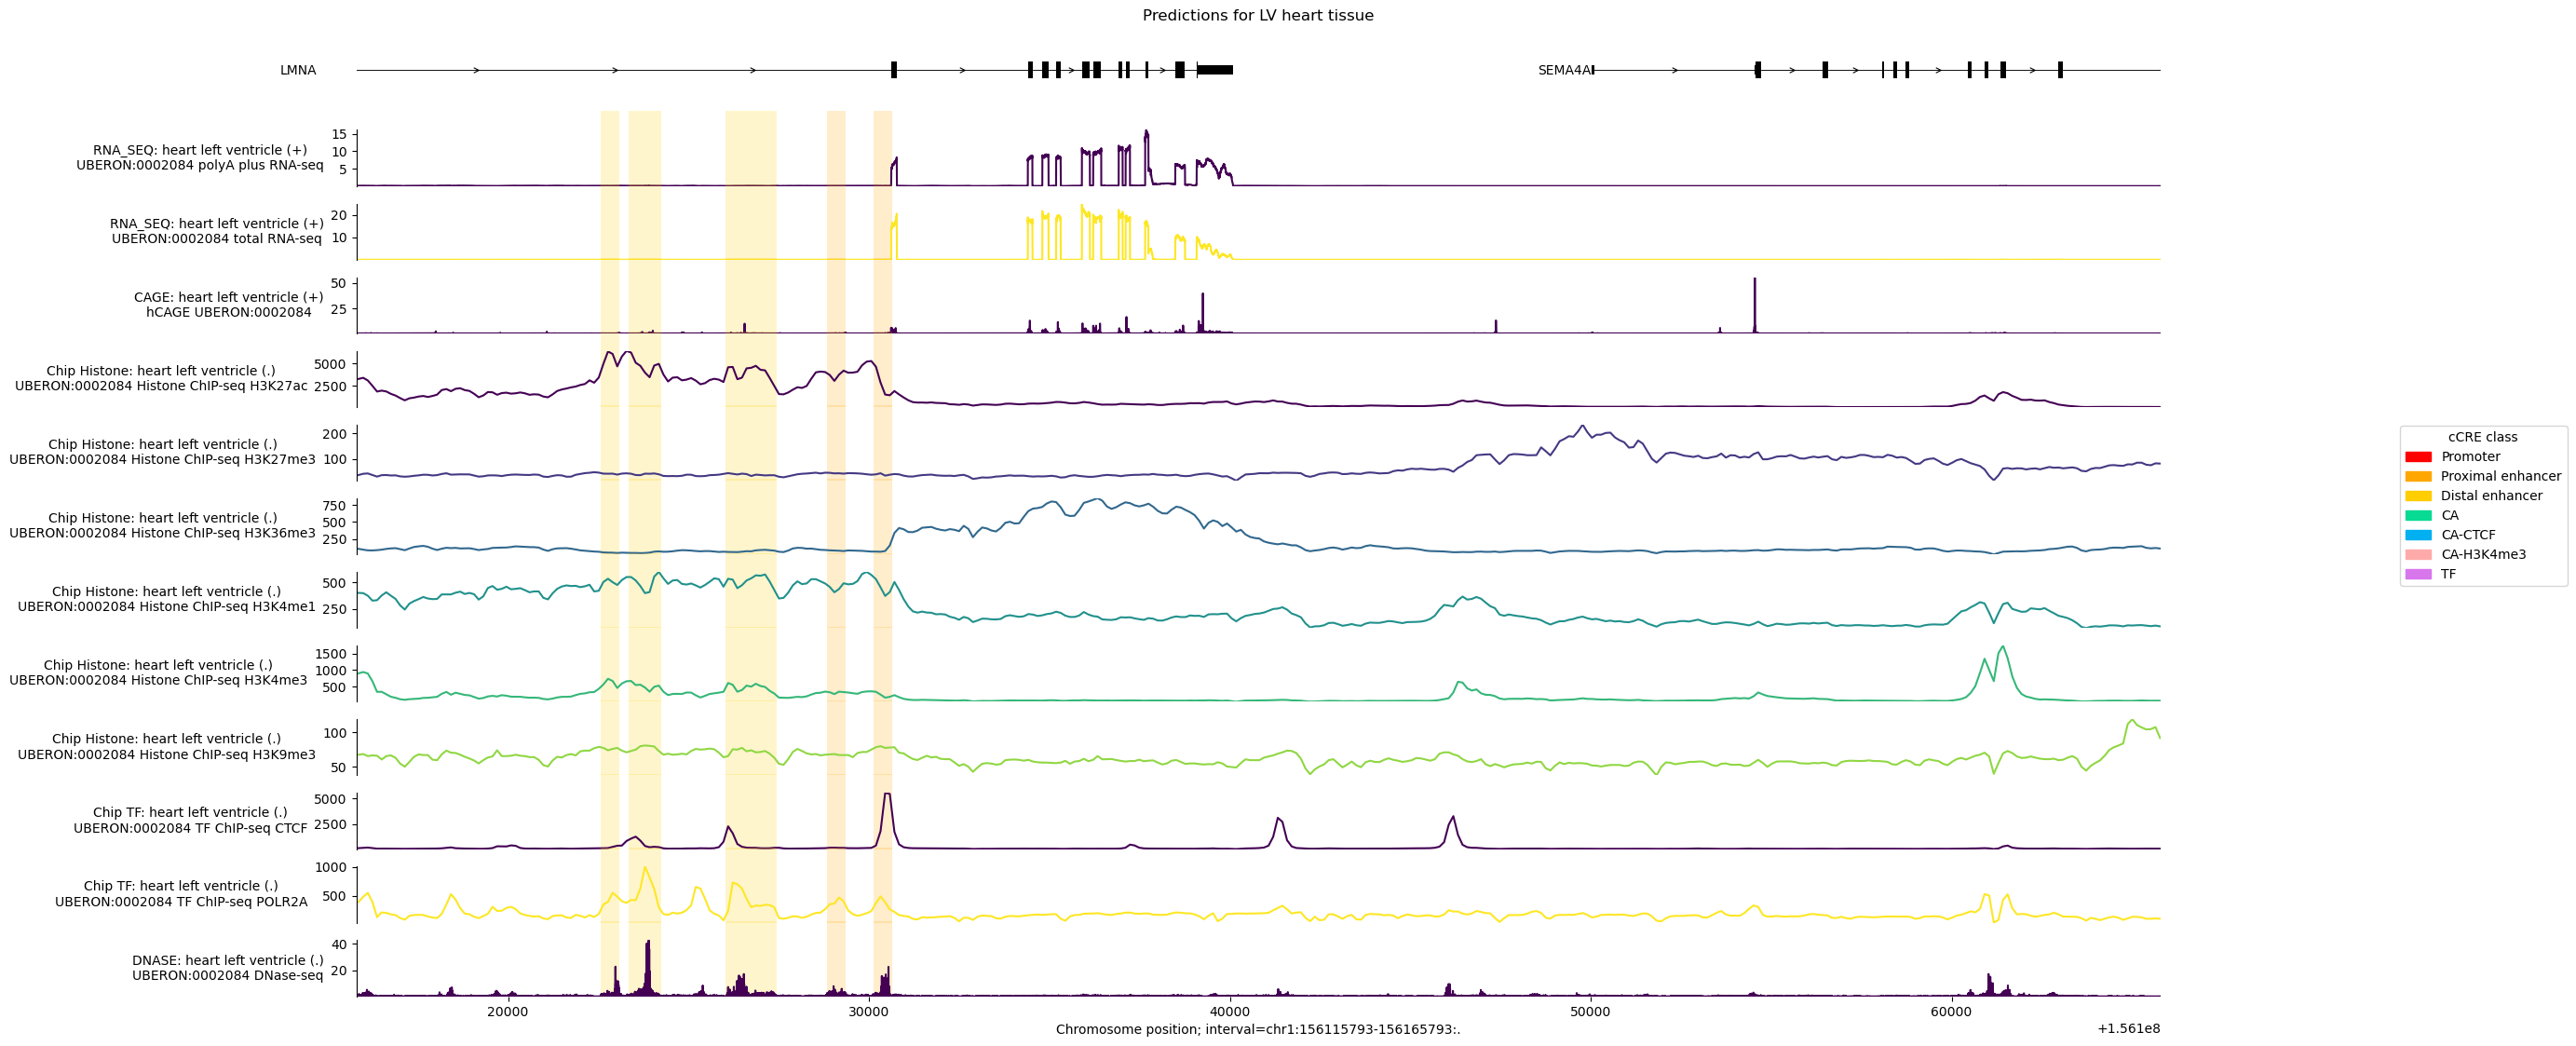

In [40]:

# plot_interval = POST_INTERVAL
plot_interval = genome.Interval('chr1', POST_INTERVAL.start, POST_INTERVAL.start + 50000)
# plot_interval = genome.Interval('chr1', PRE_INTERVAL.end - 50000, PRE_INTERVAL.end)
# plot_interval = genome.Interval('chr1', LMNA_START - 10000, LMNA_END + 10000)
save = True
add_annos = True

# Build plot.
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),
        plot_components.Tracks(
            tdata=output.rna_seq.filter_to_positive_strand(),
            ylabel_template='RNA_SEQ: {biosample_name} ({strand})\n{name}',
        ),
        plot_components.Tracks(
            tdata=output.cage.filter_to_positive_strand(),
            ylabel_template='CAGE: {biosample_name} ({strand})\n{name}',
        ),
        # Chip histone.
        plot_components.Tracks(
            tdata=output.chip_histone,
            ylabel_template='Chip Histone: {biosample_name} ({strand})\n{name}',
        ),
        # Chip tf.
        plot_components.Tracks(
            tdata=output.chip_tf,
            ylabel_template='Chip TF: {biosample_name} ({strand})\n{name}',
        ),
        #  # ATAC
        # plot_components.Tracks(
        #     tdata=output.atac,
        #     ylabel_template='ATAC: {biosample_name} ({strand})\n{name}',
        # ),
        # dnase
        plot_components.Tracks(
            tdata=output.dnase,
            ylabel_template='DNASE: {biosample_name} ({strand})\n{name}',
        ),
        #  # splice sites
        # plot_components.Tracks(
        #     tdata=output.splice_sites,
        #     ylabel_template='Splice Sites: ({strand})\n{name}',
        # ),
       
    ],
    # add annotations from a bed file (imported and parsed above)
    annotations=[
        plot_components.IntervalAnnotation(
            bed_intervals, #ccre_intervals,
            colors=colors, #ccre_colors
            alpha=0.2,
            # use_default_labels=False,   # True if you want cCRE IDs as labels
            # labels=bed_df["name"].tolist(),
        ),
    ],
     
    interval=plot_interval,
    fig_width=25,
    title='Predictions for LV heart tissue',
)

# legend_handles = [
#     mpatches.Patch(color=color, label=key) 
#     for key, color in CCRE_COLORS.items()
# ]
# plot.legend(handles=legend_handles, loc="center left", title="Categories",
#           bbox_to_anchor=(1, 0, 0.5, 1))


if OVERLAY_SOURCE == "ccre":
    # Legend follows ENCODE class color map; only classes present in this window
    label_order = list(CCRE_COLORS)
    used = [c for c in label_order if c in set(bed_df["category"])]
    handles = [
        mpatches.Patch(color=CCRE_COLORS.get(c, "gray"), label=c) for c in used
    ]
    legend_title = "cCRE class"
    fig_suffix = "ccre_like"
else:
    label_order = list(MODALITY_COLORS) + HISTONE_MARKS
    used = [c for c in label_order if c in set(bed_df["category"])]
    handles = [
        mpatches.Patch(color=color_from_category(c), label=c) for c in used
    ]
    legend_title = "Modality"
    fig_suffix = "ccres_collapsed"

plot.legend(
    handles=handles,
    title=legend_title,
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
)

if save:
    plot.savefig(
        f"figs/lmna_predictions_LV_1MB_{lmna_context}_{fig_suffix}_zoom50kb.png",
        dpi=300,
        bbox_inches="tight",
    )


# Reference notes

Background on ENCODE cCRE classes. These definitions drive `assign_ccre_class` / `classify_ccre_like_regions` above. High/low in this notebook use within-window percentiles on AlphaGenome tracks (not ENCODE genome-wide max-Z).

## ENCODE cCRE class definitions

- Promoter-like signatures (promoter) must fall within 200 bp of a TSS and have high chromatin accessibility and H3K4me3 signals.
- TSS-proximal enhancer-like signatures (proximal enhancer) have high chromatin accessibility and *H3K27ac* signals and are within 2 kb of an annotated TSS. If they are within 200 bp of a TSS, they must also have low H3K4me3 signal.
- TSS-distal enhancer-like signatures (distal enhancer) have high chromatin accessibility and *H3K27ac* signals and are farther than 2 kb from an annotated TSS.
- Chromatin accessibility + H3K4me3 (CA-H3K4me3) have high chromatin accessibility and H3K4me3 signals but low *H3K27ac* signals and do not fall within 200 bp of a TSS.
- Chromatin accessibility + CTCF (CA-CTCF) have high chromatin accessibility and CTCF signals but low H3K4me3 and *H3K27ac* signals.
- Chromatin accessibility + transcription factor (CA-TF) have high chromatin accessibility, low H3K4me3, *H3K27ac*, and CTCF signals, and are bound by a transcription factor.
- Chromatin accessibility (CA) have high chromatin accessibility and low H3K4me3, *H3K27ac*, and CTCF signals.
- Transcription factor (TF) have low chromatin accessibility, low H3K4me3, *H3K27ac*, and CTCF signals and are bound by a transcription factor.

https://github.com/weng-lab/ENCODE-cCREs/tree/master/Version-4/cCRE-Pipeline
